# 02 - Baseline Models
## Mean Baseline and OLS Regression

This notebook establishes baseline performance using:
1. Mean Baseline (predict average price for all properties)
2. OLS Linear Regression (without feature engineering)

In [1]:
# Setup
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.load_data import load_raw_data
from src.preprocess import split_data_time_based, preprocess_data
from src.models import MeanBaseline, OLSBaseline
from src.evaluate import calculate_metrics, print_metrics

%matplotlib inline

## 1. Load and Prepare Data

In [2]:
# Load data
df = load_raw_data()
print(f"Loaded {len(df)} properties with sale data")

# Time-based split
train_df, test_df = split_data_time_based(df, 'soldOn', train_ratio=0.7)
print(f"\nTrain: {len(train_df)} samples ({train_df['soldOn'].min()} to {train_df['soldOn'].max()})")
print(f"Test: {len(test_df)} samples ({test_df['soldOn'].min()} to {test_df['soldOn'].max()})")

# Preprocess WITHOUT polynomial features (baseline)
train_df, test_df, scaler = preprocess_data(train_df, test_df, 
                                             target_col='lastSoldPrice', 
                                             use_poly_features=False)

# Prepare features and target
meta_cols = ['soldOn', 'type', 'text']
target_col = 'lastSoldPrice'
feature_cols = [c for c in train_df.columns if c != target_col and c not in meta_cols]

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_test = test_df[feature_cols]
y_test = test_df[target_col]

print(f"\nFeatures: {len(feature_cols)}")
print(f"Feature names: {feature_cols[:10]}...")

Loaded 1415 properties with sale data
Time-based split:
  Train: 990 samples (1976-11-09 00:00:00 to 2018-06-28 00:00:00)
  Test:  425 samples (2018-06-29 00:00:00 to 2024-02-16 00:00:00)

Train: 990 samples (1976-11-09 00:00:00 to 2018-06-28 00:00:00)
Test: 425 samples (2018-06-29 00:00:00 to 2024-02-16 00:00:00)

Preprocessing complete:
  Features: 18
  Feature names (first 10): ['year_built', 'beds', 'baths', 'baths_full', 'baths_half', 'garage', 'lot_sqft', 'sqft', 'stories', 'property_age']...

Features: 21
Feature names: ['year_built', 'beds', 'baths', 'baths_full', 'baths_half', 'garage', 'lot_sqft', 'sqft', 'stories', 'property_age']...


## 2. Mean Baseline Model

In [3]:
# Train Mean Baseline
mean_model = MeanBaseline()
mean_model.fit(X_train, y_train)

# Predict
y_pred_mean = mean_model.predict(X_test)

# Evaluate
metrics_mean = calculate_metrics(y_test, y_pred_mean, "Mean Baseline")
print_metrics(metrics_mean)

print(f"\nMean prediction value: ${mean_model.mean_:,.2f}")


  Mean Baseline
  MAE:   $301,998.39
  RMSE:  $682,371.66
  MAPE:  232.88%
  ──────────────────────────────────────────────
  R² Score: -0.0545 (-5.45%) ✗ FAIL


Mean prediction value: $321,938.31


## 3. OLS Linear Regression (Baseline)

In [4]:
# Train OLS
ols_model = OLSBaseline()
ols_model.fit(X_train, y_train)

# Predict
y_pred_ols = ols_model.predict(X_test)

# Evaluate
metrics_ols = calculate_metrics(y_test, y_pred_ols, "OLS Baseline")
print_metrics(metrics_ols)


  OLS Baseline
  MAE:   $277,054.22
  RMSE:  $505,652.30
  MAPE:  318.24%
  ──────────────────────────────────────────────
  R² Score: 0.4210 (42.10%) ✗ FAIL



## 4. Compare Baselines

In [5]:
# Comparison table
comparison = pd.DataFrame([metrics_mean, metrics_ols])
print("\n" + "="*60)
print("BASELINE MODEL COMPARISON")
print("="*60)
print(comparison.to_string(index=False))

improvement = (metrics_ols['R2'] - metrics_mean['R2']) * 100
print(f"\nOLS improves R² by {improvement:.2f} percentage points over Mean Baseline")


BASELINE MODEL COMPARISON
        Model           MAE          RMSE        R2       MAPE
Mean Baseline 301998.391064 682371.662777 -0.054467 232.875539
 OLS Baseline 277054.216906 505652.296919  0.420978 318.239066

OLS improves R² by 47.54 percentage points over Mean Baseline


## 5. Visualize Predictions

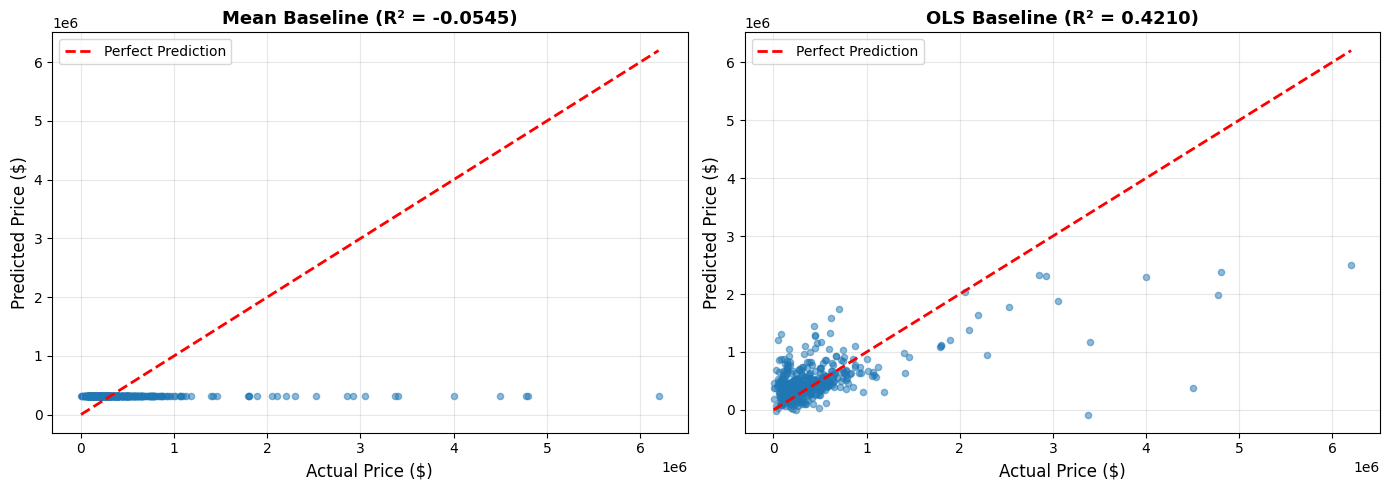

In [6]:
# Predictions vs Actual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean Baseline
axes[0].scatter(y_test, y_pred_mean, alpha=0.5, s=20)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price ($)', fontsize=12)
axes[0].set_ylabel('Predicted Price ($)', fontsize=12)
axes[0].set_title(f'Mean Baseline (R² = {metrics_mean["R2"]:.4f})', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# OLS Baseline
axes[1].scatter(y_test, y_pred_ols, alpha=0.5, s=20)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Price ($)', fontsize=12)
axes[1].set_ylabel('Predicted Price ($)', fontsize=12)
axes[1].set_title(f'OLS Baseline (R² = {metrics_ols["R2"]:.4f})', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Key Insights

**Baseline Performance:**
- Mean Baseline: Negative R² (worse than random)
- OLS Baseline: ~42% R² with raw features

**Observations:**
- Linear relationship exists but is weak with raw features
- Need feature engineering to improve performance
- Polynomial features and interactions should help

**Next Steps:**
1. Add polynomial features (squared terms)
2. Create interaction terms
3. Test regularized models (Ridge, Lasso)
4. Target: R² > 70%